# 💰 Personal Expense Tracker

### Python | Pandas | Matplotlib | JSON

A beginner-friendly personal expense management system built using Python.

---

### 🚀 Features

- ➕ Add expenses
- 👀 View expenses
- ✏️ Edit expenses
- 🗑️ Delete expenses
- 💾 Save and load data
- 🏷️ Category-wise analysis
- 💰 Budget tracking
- 🔎 Search expenses
- 📊 Data visualization
- 📈 Monthly spending analysis

# Expense Tracker - Multiple Expenses

expenses = []

while True:
    name = input("Enter expense name (or type 'done' to finish): ")

    if name.lower() == "done":
        break

    amount = float(input("Enter expense amount: ₹"))

    expense = {
        "name": name,
        "amount": amount
    }

    expenses.append(expense)

print("\n========== YOUR EXPENSES ==========")

for expense in expenses:
    print(expense["name"], "→ ₹", expense["amount"])

## 📌 Project Objective

The main objective of this project is to build a simple and
user-friendly Personal Expense Tracker using Python.

This project allows users to:

- Record daily expenses
- Organize expenses into categories
- Edit and delete expenses
- Save and load expense data
- Calculate total spending
- Analyze category-wise spending
- Track monthly expenses
- Set and monitor a budget
- Visualize spending using charts

### 🛠️ Technologies Used

- 🐍 Python
- 🐼 Pandas
- 📊 Matplotlib
- 📁 JSON
- 📓 Jupyter Notebook

## 1️⃣ Import Libraries and Load Data

This section imports the required Python libraries and loads
previously saved expenses from the JSON file.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date

# Load saved expenses
try:
    with open("expenses.json", "r") as file:
        expenses = json.load(file)
except FileNotFoundError:
    expenses = []

print("✅ Libraries loaded successfully!")
print(f"📊 Total expenses loaded: {len(expenses)}")

✅ Libraries loaded successfully!
📊 Total expenses loaded: 3


In [2]:
# Expense categories

categories = {
    "1": "Food",
    "2": "Travel",
    "3": "Bills",
    "4": "Grocery",
    "5": "Shopping",
    "6": "Education",
    "7": "Entertainment",
    "8": "Other"
}

print("✅ Expense categories loaded!")

✅ Expense categories loaded!


In [3]:
def add_expense():
    """Add a new expense to the tracker."""
    
    print("\n========== ADD EXPENSE ==========")
    
    name = input("Enter expense name: ")
    
    # Validate amount
    try:
        amount = float(input("Enter expense amount: ₹"))
        
        if amount <= 0:
            print("❌ Amount must be greater than 0.")
            return
            
    except ValueError:
        print("❌ Please enter a valid amount.")
        return
    
    # Show categories
    print("\nChoose a category:")
    
    for number, category in categories.items():
        print(f"{number}. {category}")
    
    category_choice = input("Enter category number: ")
    
    # Get category
    category = categories.get(category_choice, "Other")
    
    # Create expense
    expense = {
        "name": name,
        "amount": amount,
        "category": category,
        "date": str(date.today())
    }
    
    # Add to list
    expenses.append(expense)
    
    print("\n✅ Expense added successfully!")
    print(f"Name     : {name}")
    print(f"Amount   : ₹{amount:.2f}")
    print(f"Category : {category}")
    print(f"Date     : {date.today()}")

In [4]:
def view_expenses():
    """Display all saved expenses."""
    
    print("\n========== ALL EXPENSES ==========")
    
    if len(expenses) == 0:
        print("No expenses found.")
        return
    
    for i, expense in enumerate(expenses, start=1):
        print(
            f"{i}. "
            f"{expense['name']} | "
            f"₹{expense['amount']:.2f} | "
            f"{expense['category']} | "
            f"{expense['date']}"
        )

In [5]:
def edit_expense():
    """Edit an existing expense."""

    print("\n========== EDIT EXPENSE ==========")

    if len(expenses) == 0:
        print("No expenses available.")
        return

    # Show expenses
    for i, expense in enumerate(expenses, start=1):
        print(
            f"{i}. "
            f"{expense['name']} | "
            f"₹{expense['amount']:.2f} | "
            f"{expense['category']} | "
            f"{expense['date']}"
        )

    try:
        number = int(input("\nEnter expense number to edit: "))

        if number < 1 or number > len(expenses):
            print("❌ Invalid expense number.")
            return

        expense = expenses[number - 1]

        print("\nCurrent details:")
        print("Name:", expense["name"])
        print("Amount: ₹", expense["amount"])
        print("Category:", expense["category"])

        new_name = input("\nEnter new name: ")

        try:
            new_amount = float(input("Enter new amount: ₹"))
            
            if new_amount <= 0:
                print("❌ Amount must be greater than 0.")
                return
                
        except ValueError:
            print("❌ Please enter a valid amount.")
            return

        expense["name"] = new_name
        expense["amount"] = new_amount

        print("\n✅ Expense updated successfully!")

    except ValueError:
        print("❌ Please enter a valid expense number.")

In [6]:
def delete_expense():
    """Delete an existing expense."""

    print("\n========== DELETE EXPENSE ==========")

    if len(expenses) == 0:
        print("No expenses available.")
        return

    # Show expenses
    for i, expense in enumerate(expenses, start=1):
        print(
            f"{i}. "
            f"{expense['name']} | "
            f"₹{expense['amount']:.2f} | "
            f"{expense['category']} | "
            f"{expense['date']}"
        )

    try:
        number = int(input("\nEnter expense number to delete: "))

        if number < 1 or number > len(expenses):
            print("❌ Invalid expense number.")
            return

        deleted = expenses.pop(number - 1)

        print("\n🗑️ Expense deleted successfully!")
        print(f"Deleted: {deleted['name']}")
        print(f"Amount: ₹{deleted['amount']:.2f}")

    except ValueError:
        print("❌ Please enter a valid expense number.")

In [7]:
def total_spending():
    """Calculate and display total spending."""

    print("\n========== TOTAL SPENDING ==========")

    if len(expenses) == 0:
        print("No expenses available.")
        return

    total = sum(expense["amount"] for expense in expenses)

    print(f"💰 Total Spending: ₹{total:.2f}")

In [8]:
def category_analysis():
    """Show total spending for each category."""

    print("\n========== CATEGORY ANALYSIS ==========")

    if len(expenses) == 0:
        print("No expenses available.")
        return

    category_totals = {}

    for expense in expenses:
        category = expense["category"]
        amount = expense["amount"]

        if category in category_totals:
            category_totals[category] += amount
        else:
            category_totals[category] = amount

    for category, total in category_totals.items():
        print(f"{category:<20} ₹{total:.2f}")

In [9]:
def search_expenses():
    """Search expenses by category."""

    print("\n========== SEARCH EXPENSES ==========")

    if len(expenses) == 0:
        print("No expenses available.")
        return

    search = input("Enter category to search: ").strip().lower()

    found = False

    for i, expense in enumerate(expenses, start=1):

        if expense["category"].lower() == search:

            print(
                f"{i}. "
                f"{expense['name']} | "
                f"₹{expense['amount']:.2f} | "
                f"{expense['category']} | "
                f"{expense['date']}"
            )

            found = True

    if not found:
        print("❌ No expenses found in this category.")

In [10]:
def save_expenses():
    """Save expenses to JSON file."""

    with open("expenses.json", "w") as file:
        json.dump(expenses, file, indent=4)

    print("\n💾 Expenses saved successfully!")

# 📊 Expense Analysis Dashboard

This dashboard provides a visual analysis of personal expenses using
Pandas and Matplotlib.

In [11]:
def show_dashboard():
    """Display expense analysis dashboard."""

    if len(expenses) == 0:
        print("❌ No expenses available for dashboard.")
        return

    df = pd.DataFrame(expenses)

    df["date"] = pd.to_datetime(df["date"])

    total_spent = df["amount"].sum()
    total_expenses = len(df)

    biggest_row = df.loc[df["amount"].idxmax()]

    category_summary = (
        df.groupby("category")["amount"]
        .sum()
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 65)
    print("             📊 EXPENSE ANALYSIS DASHBOARD")
    print("=" * 65)

    print(f"\n💰 Total Spent       : ₹{total_spent:.2f}")
    print(f"🧾 Total Expenses    : {total_expenses}")
    print(f"📌 Biggest Expense   : ₹{biggest_row['amount']:.2f}")
    print(f"🛒 Biggest Purchase  : {biggest_row['name']}")

    print("\n========== EXPENSE TABLE ==========")

    display(
        df[
            ["name", "amount", "category", "date"]
        ].sort_values("date", ascending=False)
    )

    print("\n========== CATEGORY SUMMARY ==========")

    display(category_summary)

    # Category chart
    plt.figure(figsize=(8, 5))

    category_summary.plot(kind="bar")

    plt.title("Spending by Category")
    plt.xlabel("Category")
    plt.ylabel("Amount (₹)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Pie chart
    plt.figure(figsize=(7, 7))

    plt.pie(
        category_summary,
        labels=category_summary.index,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title("Expense Distribution")
    plt.show()

    # Monthly analysis
    df["month"] = df["date"].dt.strftime("%Y-%m")

    monthly_spending = (
        df.groupby("month")["amount"]
        .sum()
    )

    print("\n========== MONTHLY SPENDING ==========")

    display(monthly_spending)

    plt.figure(figsize=(8, 5))

    monthly_spending.plot(kind="bar")

    plt.title("Monthly Spending")
    plt.xlabel("Month")
    plt.ylabel("Amount (₹)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 65)
    print("              DASHBOARD COMPLETE")
    print("               =====THANKS=====")
    print("=" * 65)

In [12]:
def main_menu():
    """Run the Personal Expense Tracker."""

    while True:
        print("\n" + "=" * 55)
        print("       💰 PERSONAL EXPENSE TRACKER")
        print("=" * 55)

        print("\n1. ➕ Add Expense")
        print("2. 👀 View Expenses")
        print("3. ✏️ Edit Expense")
        print("4. 🗑️ Delete Expense")
        print("5. 💵 Total Spending")
        print("6. 🏷️ Category Analysis")
        print("7. 🔎 Search Expenses")
        print("8. 📊 Dashboard")
        print("9. 💾 Save Expenses")
        print("10. 🚪 Exit")

        choice = input("\nEnter your choice: ")

        if choice == "1":
            add_expense()

        elif choice == "2":
            view_expenses()

        elif choice == "3":
            edit_expense()

        elif choice == "4":
            delete_expense()

        elif choice == "5":
            total_spending()

        elif choice == "6":
            category_analysis()

        elif choice == "7":
            search_expenses()

        elif choice == "8":
            show_dashboard()

        elif choice == "9":
            save_expenses()

        elif choice == "10":
            save_expenses()
            print("\n👋 Thank you for using Personal Expense Tracker!")
            break

        else:
            print("\n❌ Invalid choice. Please enter 1-10.")


       💰 PERSONAL EXPENSE TRACKER

1. ➕ Add Expense
2. 👀 View Expenses
3. ✏️ Edit Expense
4. 🗑️ Delete Expense
5. 💵 Total Spending
6. 🏷️ Category Analysis
7. 🔎 Search Expenses
8. 📊 Dashboard
9. 💾 Save Expenses
10. 🚪 Exit



Enter your choice:  2



========== ALL EXPENSES ==========
1. petrol | ₹200.00 | Travel | 2026-10-01
2. electricity  | ₹478.00 | Bills | 2026-10-01
3. Face Wash | ₹199.00 | Other | 2026-10-01
4. Fruits | ₹300.00 | Food | 2026-10-02
5. Shoes | ₹1298.00 | Shopping | 2026-10-02

       💰 PERSONAL EXPENSE TRACKER

1. ➕ Add Expense
2. 👀 View Expenses
3. ✏️ Edit Expense
4. 🗑️ Delete Expense
5. 💵 Total Spending
6. 🏷️ Category Analysis
7. 🔎 Search Expenses
8. 📊 Dashboard
9. 💾 Save Expenses
10. 🚪 Exit



Enter your choice:  6



========== CATEGORY ANALYSIS ==========
Travel               ₹200.00
Bills                ₹478.00
Other                ₹199.00
Food                 ₹300.00
Shopping             ₹1298.00

       💰 PERSONAL EXPENSE TRACKER

1. ➕ Add Expense
2. 👀 View Expenses
3. ✏️ Edit Expense
4. 🗑️ Delete Expense
5. 💵 Total Spending
6. 🏷️ Category Analysis
7. 🔎 Search Expenses
8. 📊 Dashboard
9. 💾 Save Expenses
10. 🚪 Exit


...


Enter your choice:  8



             📊 EXPENSE ANALYSIS DASHBOARD

💰 Total Spent       : ₹2475.00
🧾 Total Expenses    : 5
📌 Biggest Expense   : ₹1298.00
🛒 Biggest Purchase  : Shoes

========== EXPENSE TABLE ==========


,name,amount,category,date
3,Fruits,300.0,Food,2026-10-02
4,Shoes,1298.0,Shopping,2026-10-02
0,petrol,200.0,Travel,2026-10-01
1,electricity,478.0,Bills,2026-10-01
2,Face Wash,199.0,Other,2026-10-01



========== CATEGORY SUMMARY ==========


category
Shopping    1298.0
Bills        478.0
Food         300.0
Travel       200.0
Other        199.0
Name: amount, dtype: float64

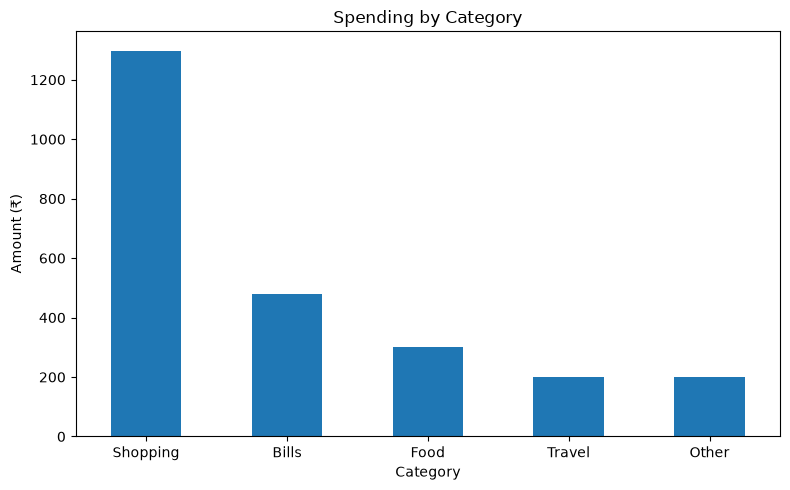

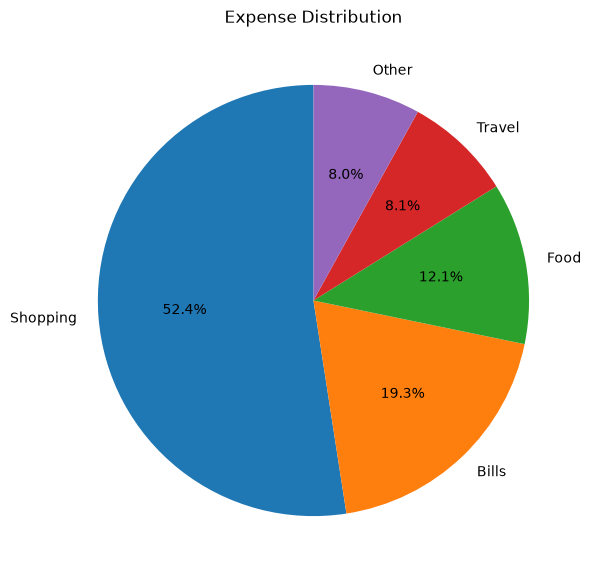


========== MONTHLY SPENDING ==========


month
2026-10    2475.0
Name: amount, dtype: float64

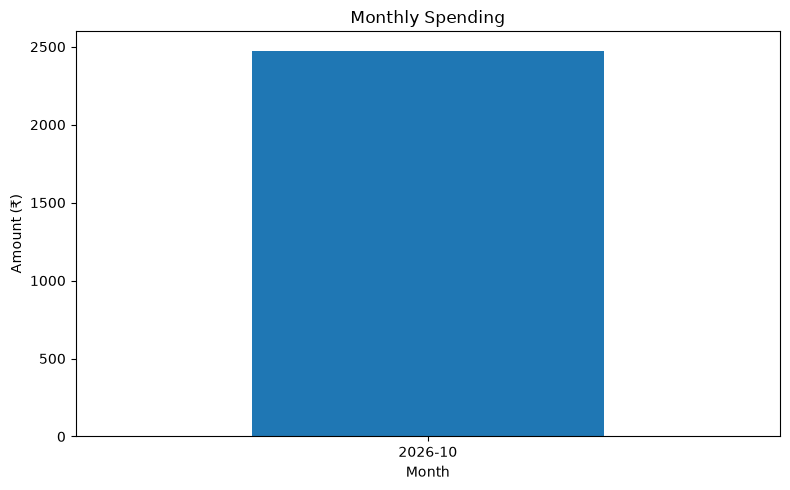


              DASHBOARD COMPLETE
               =====THANKS=====

       💰 PERSONAL EXPENSE TRACKER

1. ➕ Add Expense
2. 👀 View Expenses
3. ✏️ Edit Expense
4. 🗑️ Delete Expense
5. 💵 Total Spending
6. 🏷️ Category Analysis
7. 🔎 Search Expenses
8. 📊 Dashboard
9. 💾 Save Expenses
10. 🚪 Exit



Enter your choice:  9



💾 Expenses saved successfully!

       💰 PERSONAL EXPENSE TRACKER

1. ➕ Add Expense
2. 👀 View Expenses
3. ✏️ Edit Expense
4. 🗑️ Delete Expense
5. 💵 Total Spending
6. 🏷️ Category Analysis
7. 🔎 Search Expenses
8. 📊 Dashboard
9. 💾 Save Expenses
10. 🚪 Exit



Enter your choice:  10



💾 Expenses saved successfully!

👋 Thank you for using Personal Expense Tracker!


In [14]:
main_menu()